# Lab 0: Graded Exercises

**Course:** 25_26_SEM3_CS254_B: Introduction to Artificial Intelligence  
**Student:** Rafiatou Malam Ali  
**Student ID:** 30782027

## Exercise 4: NumPy Array Operations (20 points)

In [1]:
import numpy as np

### Task 1: Create a 5x5 border matrix (5 points)

In [2]:
# Border elements = 1, interior = 0
border_matrix = np.ones((5, 5))
border_matrix[1:4, 1:4] = 0

print("5x5 Border Matrix:")
print(border_matrix)

5x5 Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


### Task 2: Normalize a random array (5 points)

In [3]:
np.random.seed(42)
random_data = np.random.randn(100, 3)

# Normalize each column: mean=0, std=1
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("Column means (should be ~0):", normalized_data.mean(axis=0))
print("Column stds (should be ~1):", normalized_data.std(axis=0))

Column means (should be ~0): [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Column stds (should be ~1): [1. 1. 1.]


### Task 3: Linear regression using the normal equation (10 points)

In [4]:
np.random.seed(42)
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation: theta = (X^T X)^(-1) X^T y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients (theta_hat):")
print(theta_hat)
print("\nTrue coefficients (true_theta):")
print(true_theta)
print("\nDifference:")
print(theta_hat - true_theta)

Estimated coefficients (theta_hat):
[ 2.51232659 -1.21503503  3.69924591]

True coefficients (true_theta):
[ 2.5 -1.2  3.7]

Difference:
[ 0.01232659 -0.01503503 -0.00075409]


## Exercise 5: Pandas Data Analysis (30 points)

In [5]:
import pandas as pd
import numpy as np

In [6]:
# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10, replace=False), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5, replace=False), 'hours_studied'] = np.nan

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 6)


,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,NaN
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370


### Task 1: Data Cleaning and Exploration (10 points)

In [7]:
# Basic information
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
print(df.describe())

# Missing values
print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

# Fill missing exam_score with mean for student's major
major_means = df.groupby('major')['exam_score'].transform('mean')
df['exam_score'] = df['exam_score'].fillna(major_means)

# Fill missing hours_studied with median for student's year
year_medians = df.groupby('year')['hours_studied'].transform('median')
df['hours_studied'] = df['hours_studied'].fillna(year_medians)

print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB

=== Statistical Summary ===
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.507727               4.700000   
std      57.879185    1.159091    9.459179               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.0000

### Task 2: Analysis (10 points)

In [8]:
# Average exam_score by major
avg_by_major = df.groupby('major')['exam_score'].mean().sort_values(ascending=False)
print("Average exam score by major:")
print(avg_by_major)

best_major = avg_by_major.idxmax()
print(f"\nMajor with highest average: {best_major} ({avg_by_major[best_major]:.2f})")

# Correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation (hours_studied vs exam_score): {correlation:.4f}")

# Performance categories
def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize_performance)
print("\nPerformance distribution:")
print(df['performance'].value_counts())

Average exam score by major:
major
Biology    75.877440
CS         75.781493
Physics    75.333242
Math       75.017860
Name: exam_score, dtype: float64

Major with highest average: Biology (75.88)

Correlation (hours_studied vs exam_score): -0.0201

Performance distribution:
performance
Average              79
Needs Improvement    58
Good                 52
Excellent            11
Name: count, dtype: int64


### Task 3: Advanced Analysis (10 points)

In [9]:
# Analysis by major and year
grouped = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)

print("=== Stats by Major and Year ===")
print(grouped)

# Top 5 students by exam_score (ties broken by student_id)
top_5 = df.nlargest(5, ['exam_score', 'student_id'])
print("\n=== Top 5 Students ===")
print(top_5[['student_id', 'major', 'year', 'exam_score', 'hours_studied', 'performance']])

# Pivot table: average exam_score by major (rows) and year (columns)
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
).round(2)

print("\n=== Pivot Table: Avg Exam Score by Major and Year ===")
print(pivot)

=== Stats by Major and Year ===
              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13           77.25              12.68
        2               12           74.45              13.43
        3               14           80.29              15.10
        4               15           71.71              14.64
CS      1               12           74.63              13.64
        2                7           76.16              13.60
        3                9           72.35              15.04
        4               18           78.12              16.28
Math    1               11           74.55              18.22
        2                9           83.20              12.65
        3               10           72.02              15.18
        4               16           72.61              17.32
Physics 1               13           76.72              13.49
        2               12           7

## Exercise 6: Data Visualization (25 points)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('husl')

### Task 1: Distribution Visualization (8 points)

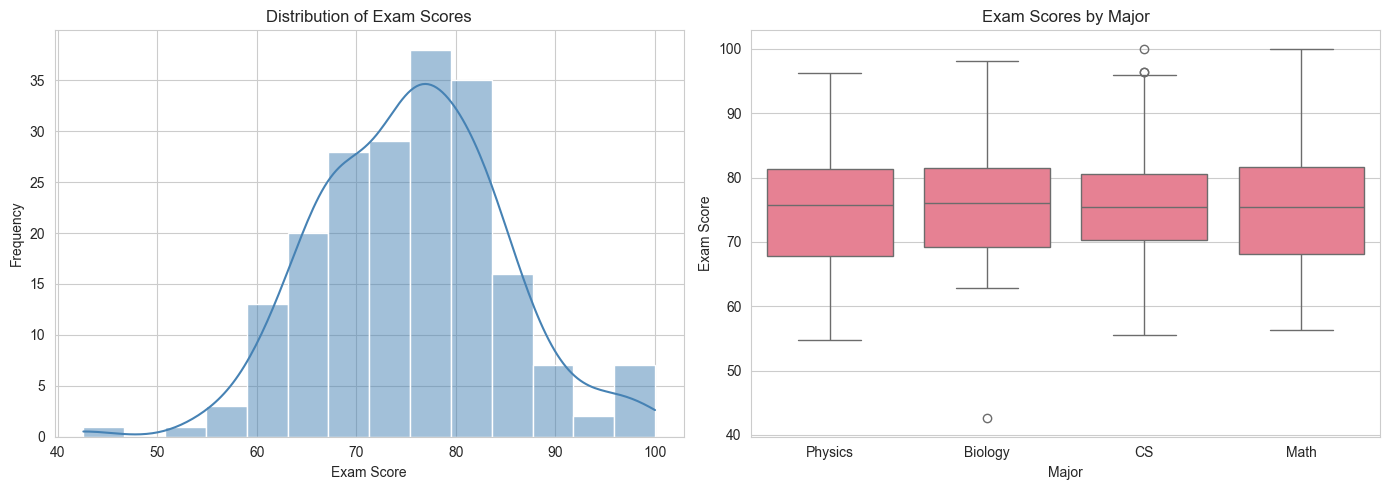

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with KDE
sns.histplot(data=df, x='exam_score', kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')

# Right: Box plot by major
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

### Task 2: Relationship Visualization (8 points)

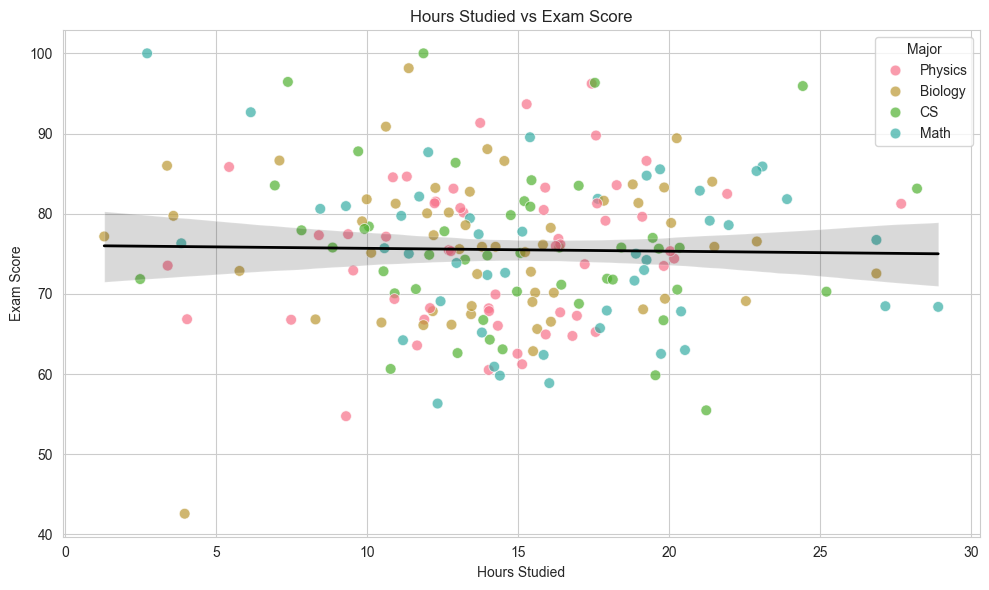

In [12]:
plt.figure(figsize=(10, 6))

# Scatter plot colored by major
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major', alpha=0.7, s=60)

# Regression line
sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False, color='black', line_kws={'linewidth': 2})

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.tight_layout()
plt.show()

### Task 3: Advanced Dashboard (9 points)

C:\Users\Rafiatou Malam Ali\AppData\Local\Temp\ipykernel_27260\2157113443.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', ax=axes[0, 1], palette='husl')


C:\Users\Rafiatou Malam Ali\AppData\Local\Temp\ipykernel_27260\2157113443.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='performance', y='exam_score', order=performance_order, ax=axes[1, 1], palette='Set2')


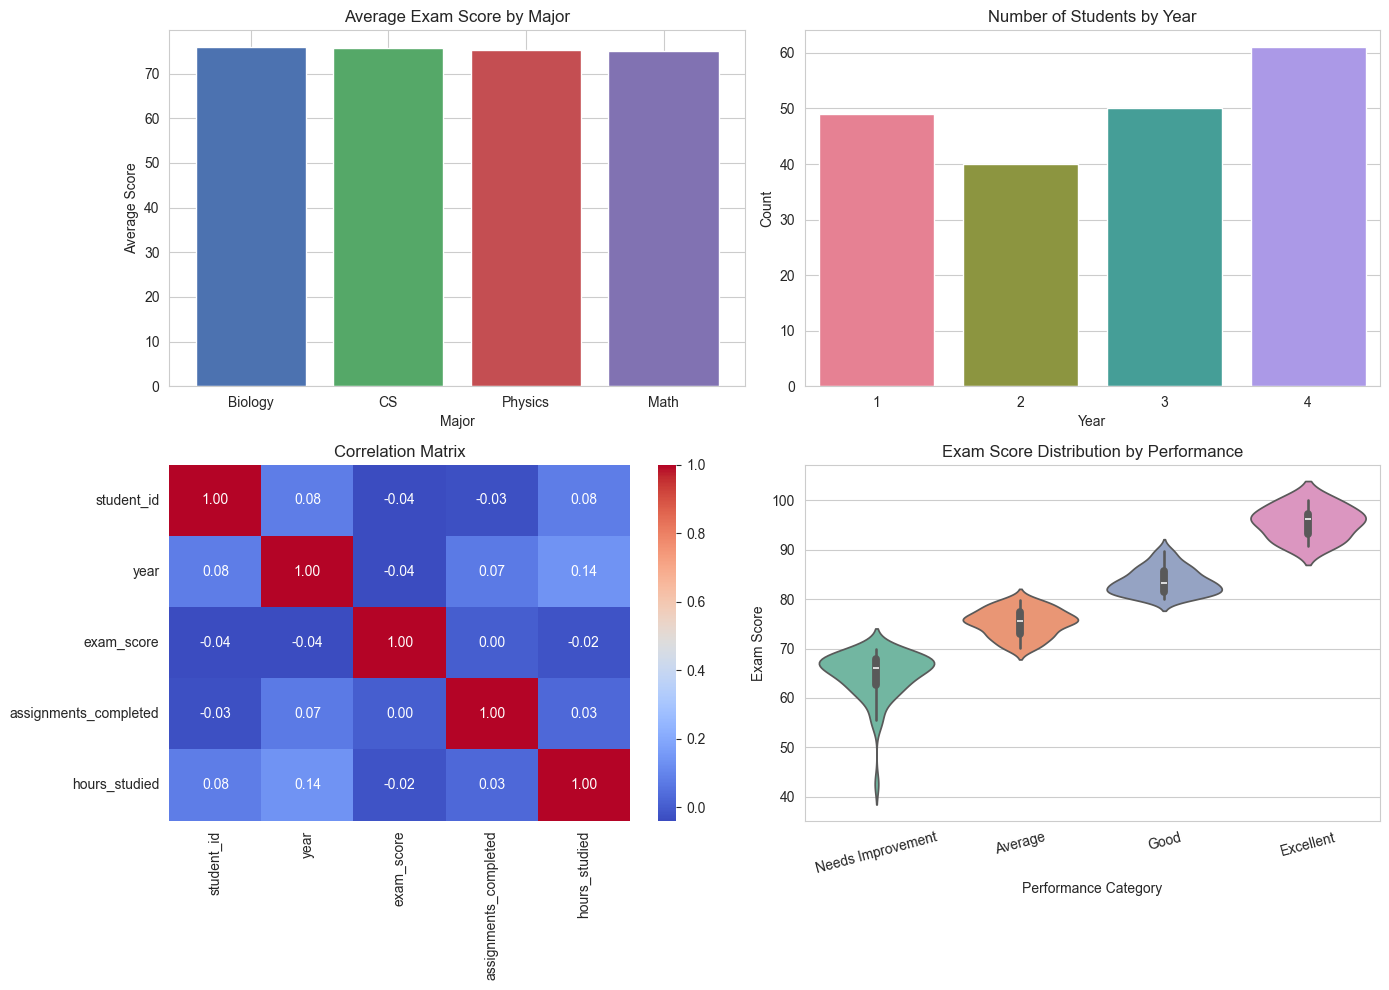

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean().sort_values(ascending=False)
axes[0, 0].bar(avg_scores.index, avg_scores.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# 2. Count plot: Number of students by year
sns.countplot(data=df, x='year', ax=axes[0, 1], palette='husl')
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. Heatmap: Correlation matrix
numerical_cols = df.select_dtypes(include=[np.number])
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance category
performance_order = ['Needs Improvement', 'Average', 'Good', 'Excellent']
sns.violinplot(data=df, x='performance', y='exam_score', order=performance_order, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Exercise 7: Integration Challenge (25 points)

In [14]:
np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

customers.head()

,age,income,purchase_frequency,avg_purchase_value
0,56,92443.123940,7,94.527456
1,69,70649.305211,2,100.932279
2,46,19612.600681,3,79.699876
3,32,40315.318543,2,130.137787
4,60,75338.222984,8,102.904845


In [15]:
# Calculate Customer Lifetime Value (CLV)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['clv'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# Create age groups
bins = [17, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels)

# Analysis by age group
age_analysis = customers.groupby('age_group', observed=True).agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('clv', 'mean'),
    total_clv=('clv', 'sum')
).round(2)

print("=== Customer Analysis by Age Group ===")
print(age_analysis)

# Top 10% customers by CLV
clv_threshold = customers['clv'].quantile(0.90)
top_10_pct = customers[customers['clv'] >= clv_threshold].sort_values('clv', ascending=False)

print(f"\nCLV threshold for top 10%: {clv_threshold:.2f}")
print(f"Number of top customers: {len(top_10_pct)}")
print("\nTop 10 customers:")
print(top_10_pct.head(10)[['age', 'age_group', 'income', 'purchase_frequency', 'clv']])

=== Customer Analysis by Age Group ===
           num_customers  avg_income  avg_clv  total_clv
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

CLV threshold for top 10%: 1222.94
Number of top customers: 50

Top 10 customers:
     age age_group        income  purchase_frequency          clv
426   42     36-50  68713.567863                   8  1645.711441
213   41     36-50  45580.608009                   7  1635.458860
410   44     36-50  49344.934596                   6  1593.874900
194   44     36-50  57331.964922                   6  1589.765308
244   28     26-35  29255.076913                   7  1584.534373
423   43     36-50  34443.666248                   6  1559.206172
386   63     51-70  24200.782005                   9  1530.342482
187   47

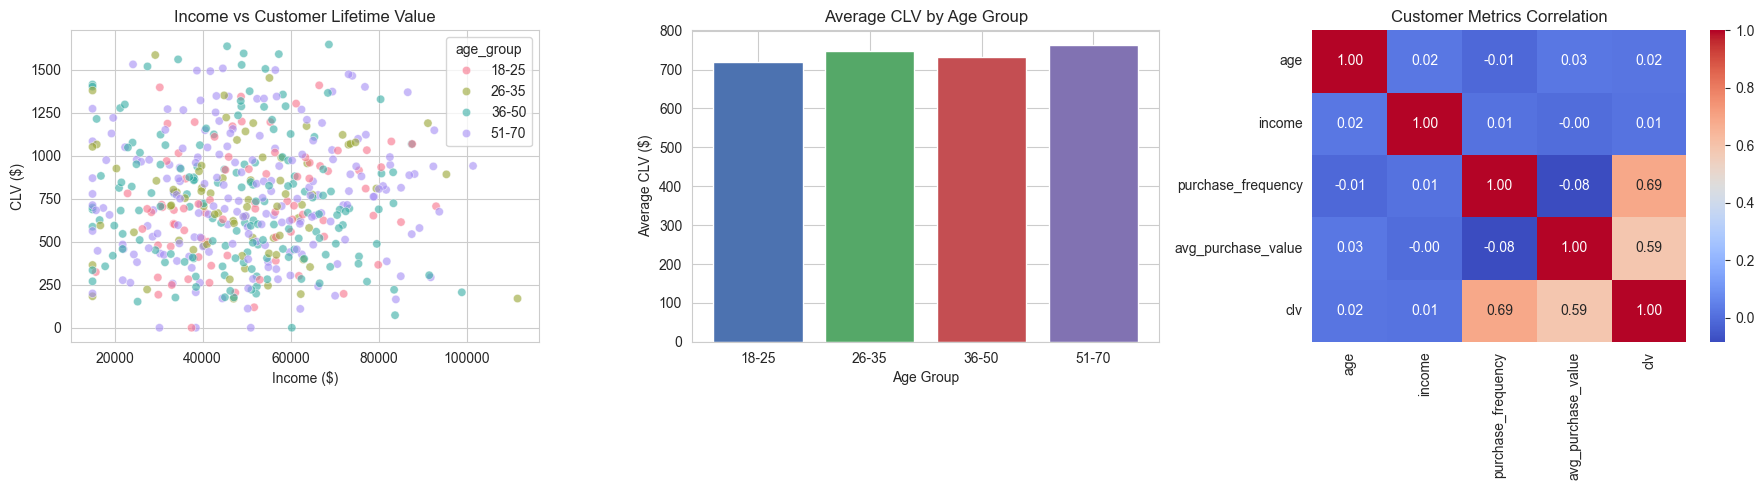

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: income vs CLV, colored by age group
sns.scatterplot(
    data=customers, x='income', y='clv', hue='age_group',
    alpha=0.6, ax=axes[0], palette='husl'
)
axes[0].set_title('Income vs Customer Lifetime Value')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('CLV ($)')

# 2. Bar chart: Average CLV by age group
avg_clv_by_age = customers.groupby('age_group', observed=True)['clv'].mean()
axes[1].bar(avg_clv_by_age.index.astype(str), avg_clv_by_age.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV ($)')

# 3. Correlation heatmap
corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'clv']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Customer Metrics Correlation')

plt.tight_layout()
plt.show()

### Analysis and Recommendations

**Key Findings:**

1. **Purchase frequency drives CLV** — CLV is strongly correlated with how often customers buy, since the formula weights frequency heavily.
2. **Age group differences** — Middle age groups (26–50) tend to have higher average income and CLV, likely due to greater purchasing power and stability.
3. **Top 10% customers** — High-CLV customers combine high purchase frequency with above-average order values; they are the most valuable segment.
4. **Income vs CLV** — Income alone does not fully predict CLV; engagement (purchase frequency) matters more.

**Recommendations:**

- Launch a **loyalty program** targeting customers with moderate frequency to increase repeat purchases.
- Create **personalized campaigns** for the top 10% CLV segment to retain high-value customers.
- Focus marketing on the **26–50 age group**, which shows the strongest CLV performance.
- Use **churn risk scores** to proactively re-engage customers with low purchase frequency before they leave.